In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

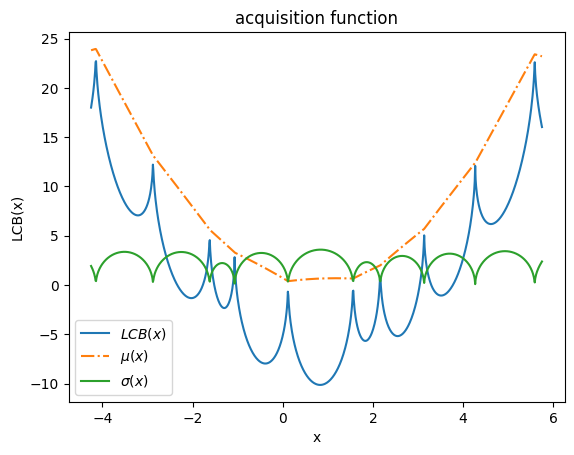

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 50
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)


for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU,l=li,u=ui)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = acqf.evaluate_meansig2(np.atleast_1d(mu_L), np.atleast_1d(s2_U))[0]
        LCB_U = acqf.evaluate_meansig2(np.atleast_1d(mu_U), np.atleast_1d(s2_L))[0]
        #LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        #LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

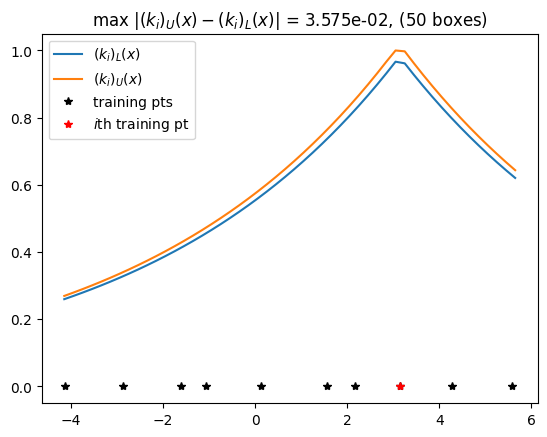

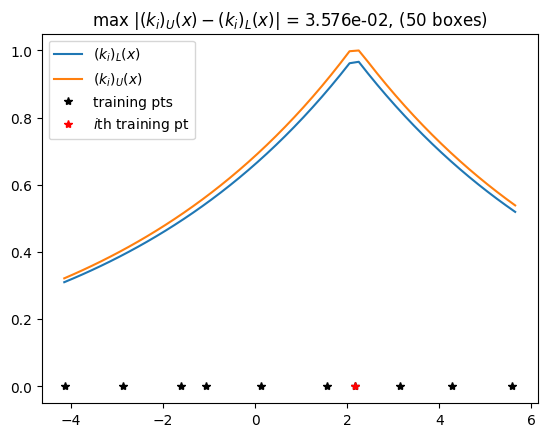

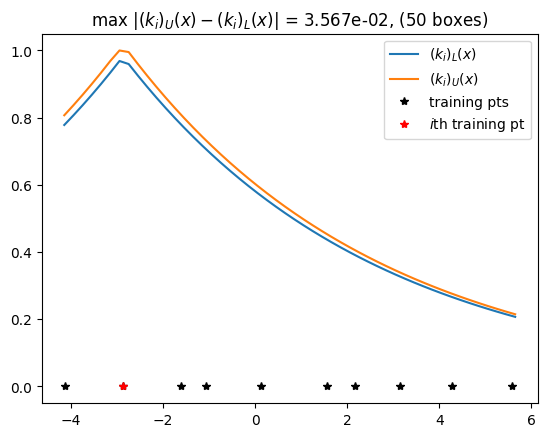

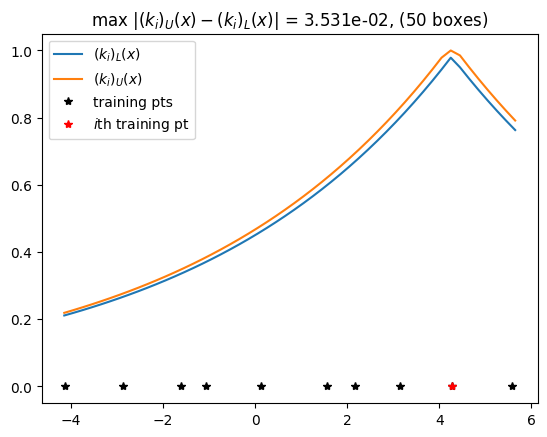

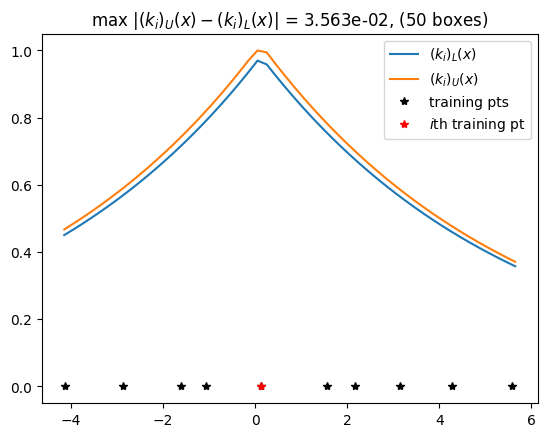

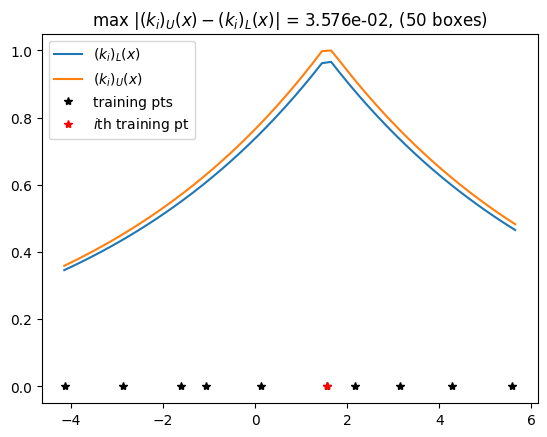

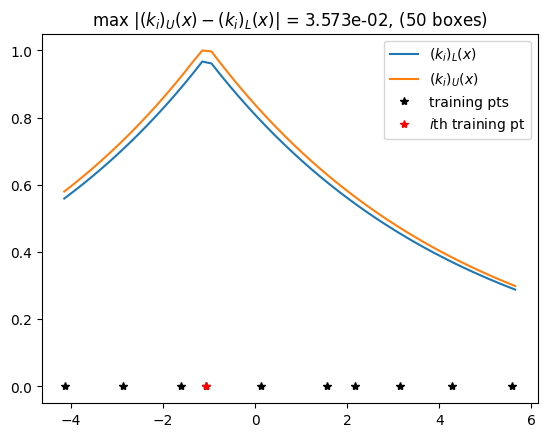

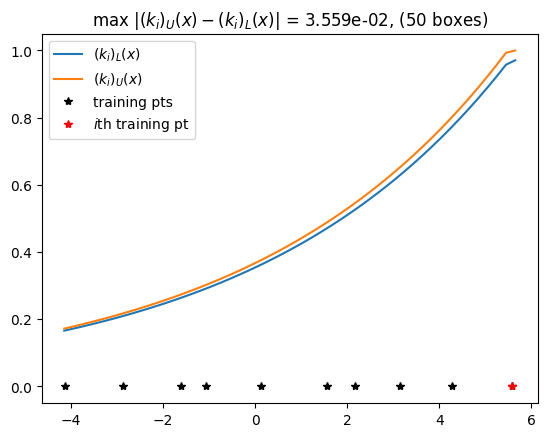

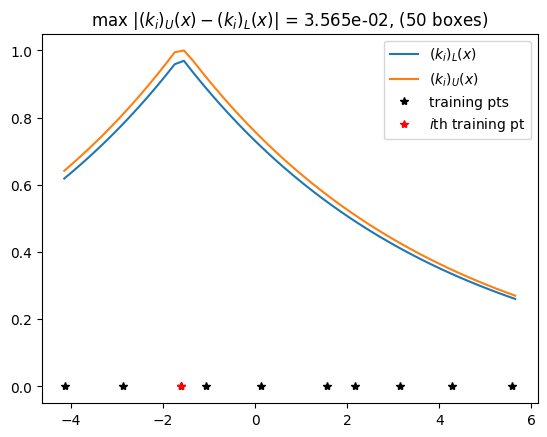

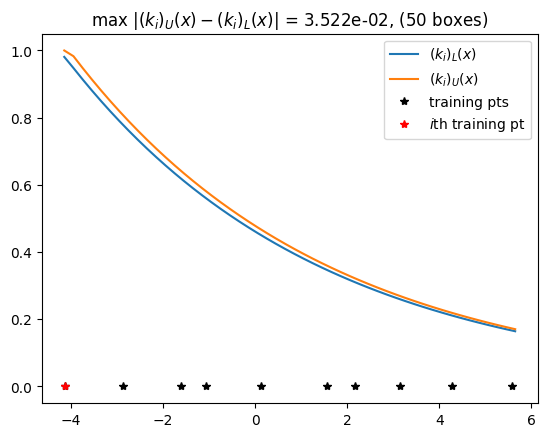

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

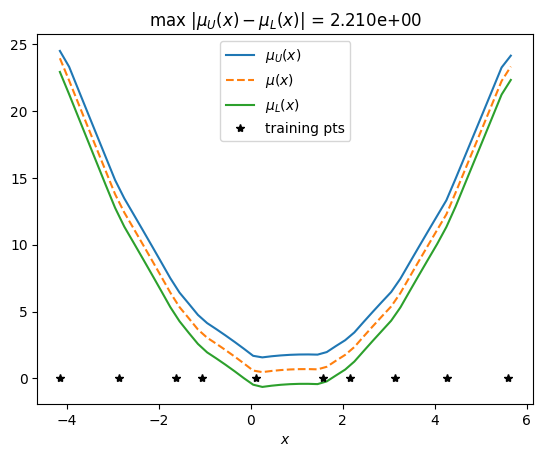

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

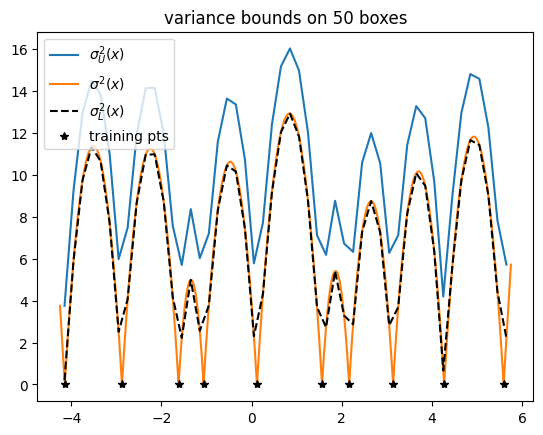

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(X, sigmaX**2., label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, "k--", label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

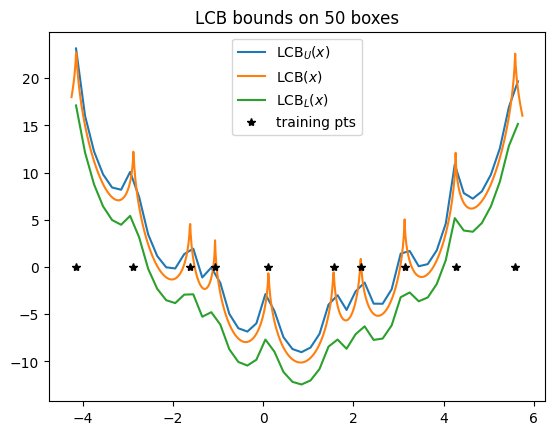

In [8]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [9]:
from hiopbbpy.opt import BnBAlgorithm

solver_options = {
    'epsilon_diam' : 1.e-12,
    'epsilon_gap' : 1.e-2,    
    'max_iter': 4000    
}


bnb = BnBAlgorithm(acqf, options=solver_options)
xstar = bnb.optimize()

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -59.24786574764444
Initial acquisition upper bound: -10.057715306466882

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-59.24786574764444, U=-10.057715306466882
Current best feasible value (LUB): -10.057715306466882
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-38.786591016744765, U=0.2879320139071204
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-38.62893110618371, U=0.6201499506669839
Queue size: 2 | LB=-38.786591016744765 | LUB=-10.057715306466882 | Gap<=28.728875710277883

--- BnB Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-38.786591016744765, U=0.2879320139071204
Current best feasible value (LUB): -10.057715306466882
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-16.677499

  Child acquisition bounds: L=-1.9955665562294858, U=6.9667271058383635
  Child pruned: L ≥ LUB + eps.
Queue size: 11 | LB=-11.954328781030306 | LUB=-10.12327420779424 | Gap<=1.8310545732360648

--- BnB Iteration 23 ---
Node bounds: l=[0.75], u=[0.90625]
Node acquisition bounds: L=-11.954328781030306, U=-10.12327420779424
Current best feasible value (LUB): -10.12327420779424
  Branching to child: l=[0.75], u=[0.828125]
  Child acquisition bounds: L=-11.035435804941116, U=-10.10594650369832
  Branching to child: l=[0.828125], u=[0.90625]
  Child acquisition bounds: L=-11.038277965570364, U=-10.109922825501135
Queue size: 12 | LB=-11.762111050109722 | LUB=-10.12327420779424 | Gap<=1.6388368423154809

--- BnB Iteration 24 ---
Node bounds: l=[-0.5], u=[-0.1875]
Node acquisition bounds: L=-11.762111050109722, U=-7.930299561556821
Current best feasible value (LUB): -10.12327420779424
  Branching to child: l=[-0.5], u=[-0.34375]
  Child acquisition bounds: L=-9.887897178614901, U=-7.937055674

  Child acquisition bounds: L=-10.19077390278032, U=-9.953149415273629
Queue size: 24 | LB=-10.381782731860335 | LUB=-10.12327420779424 | Gap<=0.2585085240660945

--- BnB Iteration 45 ---
Node bounds: l=[-0.1875], u=[0.125]
Node acquisition bounds: L=-10.381782731860335, U=-5.6951687117069
Current best feasible value (LUB): -10.12327420779424
  Branching to child: l=[-0.1875], u=[-0.03125]
  Child acquisition bounds: L=-8.957391921620266, U=-6.700038299706414
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.03125], u=[0.125]
  Child acquisition bounds: L=-7.053370181258719, U=-4.06006929680408
  Child pruned: L ≥ LUB + eps.
Queue size: 23 | LB=-10.357324854151772 | LUB=-10.12327420779424 | Gap<=0.23405064635753092

--- BnB Iteration 46 ---
Node bounds: l=[0.828125], u=[0.84765625]
Node acquisition bounds: L=-10.357324854151772, U=-10.122810014754954
Current best feasible value (LUB): -10.12327420779424
  Branching to child: l=[0.828125], u=[0.83789062]
  Child acquisition bou

  Child acquisition bounds: L=-10.1301949339123, U=-10.011660307628901
Queue size: 32 | LB=-10.23601161663254 | LUB=-10.123337743554131 | Gap<=0.1126738730784087

--- BnB Iteration 67 ---
Node bounds: l=[0.84765625], u=[0.85742188]
Node acquisition bounds: L=-10.23601161663254, U=-10.118522392773558
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.84765625], u=[0.85253906]
  Child acquisition bounds: L=-10.178334336954762, U=-10.11953630945905
  Branching to child: l=[0.85253906], u=[0.85742188]
  Child acquisition bounds: L=-10.176191536631759, U=-10.11738871236623
Queue size: 33 | LB=-10.233630258402265 | LUB=-10.123337743554131 | Gap<=0.1102925148481333

--- BnB Iteration 68 ---
Node bounds: l=[0.79882812], u=[0.80859375]
Node acquisition bounds: L=-10.233630258402265, U=-10.11604759933898
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.79882812], u=[0.80371094]
  Child acquisition bounds: L=-10.173519342411094, U=-1

  Child acquisition bounds: L=-10.149367711138373, U=-10.119941144829033
Queue size: 49 | LB=-10.176191536631759 | LUB=-10.123337743554131 | Gap<=0.05285379307762739

--- BnB Iteration 91 ---
Node bounds: l=[0.85253906], u=[0.85742188]
Node acquisition bounds: L=-10.176191536631759, U=-10.11738871236623
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.85253906], u=[0.85498047]
  Child acquisition bounds: L=-10.147385208316267, U=-10.117970524502812
  Branching to child: l=[0.85498047], u=[0.85742188]
  Child acquisition bounds: L=-10.146193076702879, U=-10.116776953092604
Queue size: 50 | LB=-10.17615036971196 | LUB=-10.123337743554131 | Gap<=0.052812626157829

--- BnB Iteration 92 ---
Node bounds: l=[0.80371094], u=[0.80859375]
Node acquisition bounds: L=-10.17615036971196, U=-10.117310134495161
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.80371094], u=[0.80615234]
  Child acquisition bounds: L=-10.14612969090612, U

  Child acquisition bounds: L=-10.137737668967846, U=-10.123026388874052
Queue size: 64 | LB=-10.152028351476346 | LUB=-10.123337743554131 | Gap<=0.028690607922214895

--- BnB Iteration 114 ---
Node bounds: l=[0.83789062], u=[0.84033203]
Node acquisition bounds: L=-10.152028351476346, U=-10.122617315422977
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.83789062], u=[0.83911133]
  Child acquisition bounds: L=-10.137426436563246, U=-10.122717405788883
  Branching to child: l=[0.83911133], u=[0.84033203]
  Child acquisition bounds: L=-10.137218748300235, U=-10.122509743675783
Queue size: 65 | LB=-10.152009005844016 | LUB=-10.123337743554131 | Gap<=0.028671262289885036

--- BnB Iteration 115 ---
Node bounds: l=[0.82080078], u=[0.82324219]
Node acquisition bounds: L=-10.152009005844016, U=-10.122591417949922
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.82080078], u=[0.82202148]
  Child acquisition bounds: L=-10.13719447

  Child acquisition bounds: L=-10.128366957430822, U=-10.113653339309156
Queue size: 79 | LB=-10.143371635160893 | LUB=-10.123337743554131 | Gap<=0.0200338916067615

--- BnB Iteration 137 ---
Node bounds: l=[0.79882812], u=[0.80126953]
Node acquisition bounds: L=-10.143371635160893, U=-10.113928468947087
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.79882812], u=[0.80004883]
  Child acquisition bounds: L=-10.128274569581315, U=-10.113548979156352
  Branching to child: l=[0.80004883], u=[0.80126953]
  Child acquisition bounds: L=-10.129025051750762, U=-10.114300442280493
Queue size: 80 | LB=-10.142372120713262 | LUB=-10.123337743554131 | Gap<=0.019034377159130145

--- BnB Iteration 138 ---
Node bounds: l=[1.0234375], u=[1.0625]
Node acquisition bounds: L=-10.142372120713262, U=-9.661663046872091
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[1.0234375], u=[1.04296875]
  Child acquisition bounds: L=-9.944645023552182, U

  Child acquisition bounds: L=-10.130290328146547, U=-10.122934900497633
  Branching to child: l=[0.83728027], u=[0.83789062]
  Child acquisition bounds: L=-10.130208923663966, U=-10.122853513702688
Queue size: 91 | LB=-10.13758652460044 | LUB=-10.123337743554131 | Gap<=0.014248781046308778

--- BnB Iteration 159 ---
Node bounds: l=[0.82324219], u=[0.82446289]
Node acquisition bounds: L=-10.13758652460044, U=-10.122874861573635
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.82324219], u=[0.82385254]
  Child acquisition bounds: L=-10.130189057997972, U=-10.12283230058598
  Branching to child: l=[0.82385254], u=[0.82446289]
  Child acquisition bounds: L=-10.130272208748831, U=-10.122915550843665
Queue size: 92 | LB=-10.137426436563246 | LUB=-10.123337743554131 | Gap<=0.014088693009114195

--- BnB Iteration 160 ---
Node bounds: l=[0.83789062], u=[0.83911133]
Node acquisition bounds: L=-10.137426436563246, U=-10.122717405788883
Current best feasible value

  Child acquisition bounds: L=-10.1280905212803, U=-10.12073493066395
  Branching to child: l=[0.8470459], u=[0.84765625]
  Child acquisition bounds: L=-10.127889468780802, U=-10.120533836385174
Queue size: 103 | LB=-10.135299998494087 | LUB=-10.123337743554131 | Gap<=0.011962254939955841

--- BnB Iteration 179 ---
Node bounds: l=[0.81347656], u=[0.81469727]
Node acquisition bounds: L=-10.135299998494087, U=-10.120584199351203
Current best feasible value (LUB): -10.123337743554131
  Branching to child: l=[0.81347656], u=[0.81408691]
  Child acquisition bounds: L=-10.127840565456525, U=-10.120481709050122
  Branching to child: l=[0.81408691], u=[0.81469727]
  Child acquisition bounds: L=-10.128043512915166, U=-10.120684815678796
Queue size: 104 | LB=-10.135170282381322 | LUB=-10.123337743554131 | Gap<=0.01183253882719093

--- BnB Iteration 180 ---
Node bounds: l=[0.75976562], u=[0.76464844]
Node acquisition bounds: L=-10.135170282381322, U=-10.07613255265773
Current best feasible value 

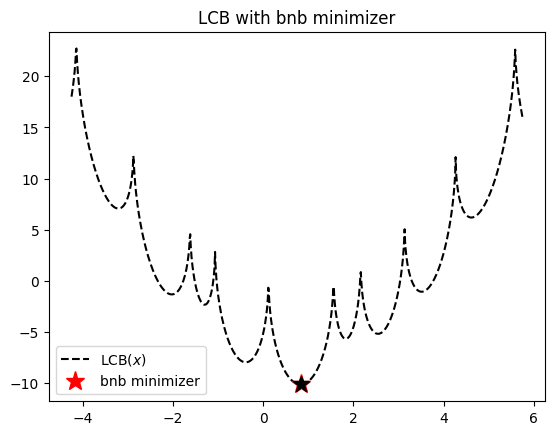

In [10]:
y_star = acqf.evaluate(xstar)
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
ystar_true = acqf.evaluate(xstar_true)
#print(xstar_true)
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
plt.plot(xstar_true, ystar_true, "k*", markersize=12)
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()


In [11]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'solver_options' : solver_options,
}

In [12]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 3
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: SLSQP
hiopbbpy Internal optimization solver options: {'epsilon_diam': 1e-12, 'epsilon_gap': 0.01, 'max_iter': 4000}
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Logger level: INFO
hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 3.9947e-01 
hiopbbpy Best CONSTRAINED objective from 10 feasible initial samples: 3.9947e-01
hiopbbpy *****************************
hiopbbpy Iteration 1/3
hiopbbpy In batch 1/1
hiopbbpy Start finding the best sampling point:


=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -59.247865745016
Initial acquisition upper bound: -10.057715306616412

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-59.247865745016, U=-10.057715306616412
Current best feasible value (LUB): -10.057715306616412
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-38.78659101561805, U=0.2879320138046024
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-38.62893110505509, U=0.6201499505698962
Queue size: 2 | LB=-38.78659101561805 | LUB=-10.057715306616412 | Gap<=28.72887570900164

--- BnB Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-38.78659101561805, U=0.2879320138046024
Current best feasible value (LUB): -10.057715306616412
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-16.67749918267640

  Child acquisition bounds: L=-11.05786762629245, U=-9.11309165183076
  Branching to child: l=[1.21875], u=[1.375]
  Child acquisition bounds: L=-9.810403707442559, U=-7.661111012186263
  Child pruned: L ≥ LUB + eps.
Queue size: 13 | LB=-12.267318595612895 | LUB=-10.123274207944565 | Gap<=2.1440443876683304

--- BnB Iteration 21 ---
Node bounds: l=[2.], u=[2.625]
Node acquisition bounds: L=-12.267318595612895, U=-3.822826930832653
Current best feasible value (LUB): -10.123274207944565
  Branching to child: l=[2.], u=[2.3125]
  Child acquisition bounds: L=-6.766456421432903, U=0.5893671350382008
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[2.3125], u=[2.625]
  Child acquisition bounds: L=-9.178068467940385, U=-5.041978826204095
  Child pruned: L ≥ LUB + eps.
Queue size: 12 | LB=-12.177943261175047 | LUB=-10.123274207944565 | Gap<=2.054669053230482

--- BnB Iteration 22 ---
Node bounds: l=[3.25], u=[4.5]
Node acquisition bounds: L=-12.177943261175047, U=0.97688751884567
Curren

  Child acquisition bounds: L=-10.356411222043961, U=-10.121822334567076
Queue size: 18 | LB=-10.559703064496683 | LUB=-10.123274207944565 | Gap<=0.4364288565521175

--- BnB Iteration 39 ---
Node bounds: l=[0.8671875], u=[0.90625]
Node acquisition bounds: L=-10.559703064496683, U=-10.091735059685954
Current best feasible value (LUB): -10.123274207944565
  Branching to child: l=[0.8671875], u=[0.88671875]
  Child acquisition bounds: L=-10.336517084594954, U=-10.101790658454535
  Branching to child: l=[0.88671875], u=[0.90625]
  Child acquisition bounds: L=-10.314764604926765, U=-10.07975122718159
Queue size: 19 | LB=-10.554568707111345 | LUB=-10.123274207944565 | Gap<=0.4312944991667802

--- BnB Iteration 40 ---
Node bounds: l=[0.75], u=[0.7890625]
Node acquisition bounds: L=-10.554568707111345, U=-10.085719128496132
Current best feasible value (LUB): -10.123274207944565
  Branching to child: l=[0.75], u=[0.76953125]
  Child acquisition bounds: L=-10.30823107017338, U=-10.07269344736092

  Child acquisition bounds: L=-10.16769201251888, U=-10.049491035318212
Queue size: 30 | LB=-10.276447898374377 | LUB=-10.123281548489382 | Gap<=0.15316634988499445

--- BnB Iteration 59 ---
Node bounds: l=[0.6328125], u=[0.671875]
Node acquisition bounds: L=-10.276447898374377, U=-9.797744659265739
Current best feasible value (LUB): -10.123281548489382
  Branching to child: l=[0.6328125], u=[0.65234375]
  Child acquisition bounds: L=-10.0013200094982, U=-9.76034975485474
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.65234375], u=[0.671875]
  Child acquisition bounds: L=-10.072708659135559, U=-9.833004383731407
  Child pruned: L ≥ LUB + eps.
Queue size: 29 | LB=-10.248355899327754 | LUB=-10.123281548489382 | Gap<=0.12507435083837137

--- BnB Iteration 60 ---
Node bounds: l=[0.92578125], u=[0.9453125]
Node acquisition bounds: L=-10.248355899327754, U=-10.01239747649528
Current best feasible value (LUB): -10.123281548489382
  Branching to child: l=[0.92578125], u=[0.93554688]

...

  Child acquisition bounds: L=-6.5655315027940615, U=-6.547319611226987
  Branching to child: l=[0.49243164], u=[0.49365234]
  Child acquisition bounds: L=-6.565030986537289, U=-6.546816949270727
Queue size: 64 | LB=-6.5827442577070325 | LUB=-6.548674261888215 | Gap<=0.03406999581881731

--- BnB Iteration 136 ---
Node bounds: l=[0.47412109], u=[0.4765625]
Node acquisition bounds: L=-6.5827442577070325, U=-6.546369316462609
Current best feasible value (LUB): -6.548674261888215
  Branching to child: l=[0.47412109], u=[0.4753418]
  Child acquisition bounds: L=-6.564254802372393, U=-6.546057854820529
  Branching to child: l=[0.4753418], u=[0.4765625]
  Child acquisition bounds: L=-6.564858141759571, U=-6.546661057778855
Queue size: 65 | LB=-6.582740789964957 | LUB=-6.548674261888215 | Gap<=0.0340665280767416

--- BnB Iteration 137 ---
Node bounds: l=[0.52050781], u=[0.52539062]
Node acquisition bounds: L=-6.582740789964957, U=-6.509607733861515
Current best feasible value (LUB): -6.5486742

  Child acquisition bounds: L=-6.556962312334076, U=-6.538722421842798
  Branching to child: l=[0.50463867], u=[0.50585938]
  Child acquisition bounds: L=-6.555668761282601, U=-6.537425265911405
Queue size: 61 | LB=-6.57377989608954 | LUB=-6.548674261888215 | Gap<=0.025105634201325167

--- BnB Iteration 159 ---
Node bounds: l=[1.16015625], u=[1.16503906]
Node acquisition bounds: L=-6.57377989608954, U=-6.501536326187408
Current best feasible value (LUB): -6.548674261888215
  Branching to child: l=[1.16015625], u=[1.16259766]
  Child acquisition bounds: L=-6.53667493548762, U=-6.500508557582957
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.16259766], u=[1.16503906]
  Child acquisition bounds: L=-6.538638582486413, U=-6.502487159085825
  Child pruned: L ≥ LUB + eps.
Queue size: 60 | LB=-6.572778951513188 | LUB=-6.548674261888215 | Gap<=0.024104689624972586

--- BnB Iteration 160 ---
Node bounds: l=[0.46191406], u=[0.46435547]
Node acquisition bounds: L=-6.572778951513188, U=-

  Child acquisition bounds: L=-6.556405247341907, U=-6.547304131623143
Queue size: 72 | LB=-6.565375137569543 | LUB=-6.548674625584848 | Gap<=0.0167005119846948

--- BnB Iteration 183 ---
Node bounds: l=[0.51074219], u=[0.51318359]
Node acquisition bounds: L=-6.565375137569543, U=-6.528862577826662
Current best feasible value (LUB): -6.548674625584848
  Branching to child: l=[0.51074219], u=[0.51196289]
  Child acquisition bounds: L=-6.548004829791679, U=-6.529741086266976
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.51196289], u=[0.51318359]
  Child acquisition bounds: L=-6.5462322513628495, U=-6.527964010502299
  Child pruned: L ≥ LUB + eps.
Queue size: 71 | LB=-6.565030986537289 | LUB=-6.548674625584848 | Gap<=0.016356360952441307

--- BnB Iteration 184 ---
Node bounds: l=[0.49243164], u=[0.49365234]
Node acquisition bounds: L=-6.565030986537289, U=-6.546816949270727
Current best feasible value (LUB): -6.548674625584848
  Branching to child: l=[0.49243164], u=[0.4930419

hiopbbpy   (mu, sigma) at new sample x: 0.21980940356789702, 2.256161343050915 
hiopbbpy Best objective found in this iteration: 7.0330e-02 
hiopbbpy Training set size is now 13
hiopbbpy Current best objective: 6.4909e-03 (previous best: 6.4909e-03)
hiopbbpy Objective function improvement: 0.0000e+00
hiopbbpy ===================================
hiopbbpy Bayesian Optimization completed
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for BO iterations: 3
hiopbbpy Optimal at BO iteration: 1 
hiopbbpy Best value: 0.006490945816040039
hiopbbpy ===================================


  Child acquisition bounds: L=-6.550160427381223, U=-6.541058569675213
Queue size: 81 | LB=-6.558759691767793 | LUB=-6.548674625584848 | Gap<=0.01008506618294458

--- BnB Iteration 206 ---
Node bounds: l=[0.40820312], u=[0.41796875]
Node acquisition bounds: L=-6.558759691767793, U=-6.412273848243363
Current best feasible value (LUB): -6.548674625584848
  Branching to child: l=[0.40820312], u=[0.41308594]
  Child acquisition bounds: L=-6.47619680448173, U=-6.402736034623105
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.41308594], u=[0.41796875]
  Child acquisition bounds: L=-6.494823624437189, U=-6.42148151191573
  Child pruned: L ≥ LUB + eps.
Queue size: 80 | LB=-6.558176290061848 | LUB=-6.548674625584848 | Gap<=0.00950166447699985

--- BnB Iteration 207 ---
Node bounds: l=[0.50219727], u=[0.50341797]
Node acquisition bounds: L=-6.558176290061848, U=-6.539939857109481
Current best feasible value (LUB): -6.548674625584848
STOP: LUB - Node.L = 0.00950166447699985 <= 0.01

===

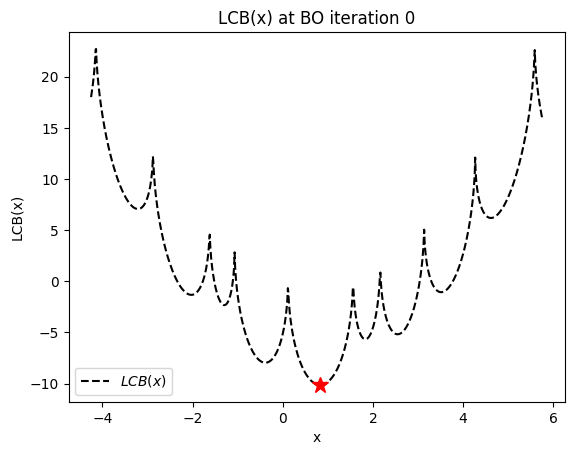

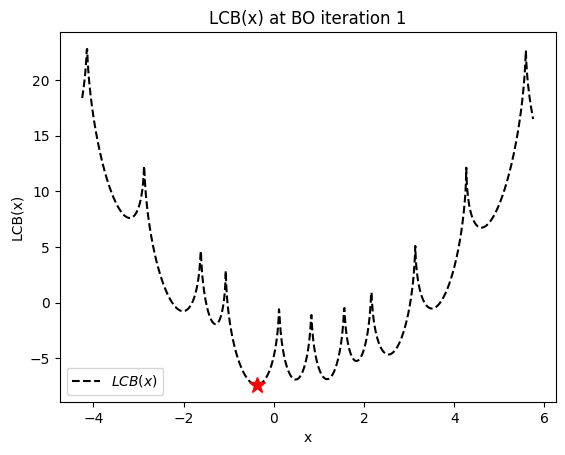

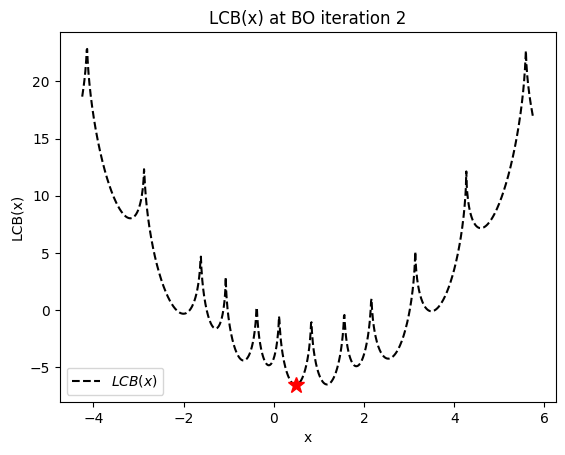

In [13]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    